In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

In [2]:
from catboost import CatBoostRegressor

In [3]:
RANDOM_STATE = 12345

CATIGORIES_TRIM = ["base", "extra level touring", "limited", "luxury touring", "level extra", "standard level extra", "standard level touring", "classic edition", "custom edition",
              "deluxe", "deluxe level", "extra", "grand touring", "luxury","luxury edition", "luxury sport", "luxury special", "luxury touring", "sport edition", 
              "special edition", "special equipment","standart level", "standart", "special version", "touring", 
              "xlt", "ltd", "ltz", "gle", "sle", "slt", "ce",  "dx",  "dl",  "ex",  "gl",  "gt", "lx",  "le", "sl", "sv",  "ls", "lt",  "se",]

CATIGORIES_COLUMNS = ["make", "model", "trim", "body", "transmission", "state", "color", "interior"]

In [4]:
data_train = pd.read_csv("./used-cars-price-prediction-19ds/train.csv")
data_test = pd.read_csv("./used-cars-price-prediction-19ds/test.csv")

In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440236 entries, 0 to 440235
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          440236 non-null  int64  
 1   make          432193 non-null  object 
 2   model         432113 non-null  object 
 3   trim          431899 non-null  object 
 4   body          429843 non-null  object 
 5   transmission  388775 non-null  object 
 6   vin           440236 non-null  object 
 7   state         440236 non-null  object 
 8   condition     430831 non-null  float64
 9   odometer      440167 non-null  float64
 10  color         439650 non-null  object 
 11  interior      439650 non-null  object 
 12  seller        440236 non-null  object 
 13  sellingprice  440236 non-null  int64  
 14  saledate      440236 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 50.4+ MB


In [6]:
def make_unique(data):
    if "ford" in data:
        return "ford"
    if "gmc" in data:
        return "gmc"
    if "land" in data:
        return "landrover"
    if "mercedes" in data:
        return "mercedes"
    if data == "vw":
        return "volkswagen"
    if "dodge" in data:
        return "dodge"
    if "mazda" in data:
        return "mazda"
    else:
        return data

In [7]:
def body_unique(data):
    if data.find("cab") != -1 or data == "koup":
        return "pick-up"
    if data.find("convertible") != -1:
        return "convertible"
    if data.find("coupe") != -1:
        return "coupe"
    if data.find("wagon") != -1:
        return "wagon"
    if data.find("van") != -1:
        return "van"
    if data.find("sedan") != -1:
        return "sedan"
    if data.find("van") != -1:
        return "van"
    else:
        return data

In [8]:
def trim_unique(data):

    def classify_trim_levels(trim_levels, category):
        for trim_level in trim_levels:
            if trim_level in category:
                return trim_level
        return "unknown"

    trim = classify_trim_levels(CATIGORIES_COLUMNS, data)
    if trim == "extra level touring":
        return "xlt"
    if trim == "limited":
        return "ltd"
    if trim == "luxury touring":
        return "ltz"
    if trim == "level extra":
        return "gle"
    if trim == "standard level extra":
        return "sle"
    if trim == "standard level touring":
        return "slt"
    if trim == "classic edition" or trim == "custom edition":
        return "ce"
    if trim == "deluxe":
        return "dx"
    if trim == "deluxe level":
        return "dl"
    if trim == "extra":
        return "ex"
    if trim == "grade level":
        return "gl"
    if trim == "grand touring":
        return "gt"
    if trim == "luxury":
        return "lx"
    if trim == "luxury edition":
        return "le"
    if trim == "luxury sport":
        return "ls"
    if trim == "luxury touring":
        return "lt"
    if trim == "sport edition" or trim == "special edition" or trim =="special equipment":
        return "se"
    if trim == "standart level" or trim == "standart":
        return "sl"
    if trim == "special version":
        return "sv"
    if trim == "touring":
        return "t"
    else:
        return trim

In [9]:
def getfullitemsforOHE(wholedf,featlist,sort=True):
    def sortornot(X):
        if sort==False:
            return X
        else:
            return sorted(X)
       
    fulllist=[]
    for feat in featlist:
        fulllist.append(sortornot(wholedf[feat].unique()))
    return fulllist

In [10]:
def preprocessing(data):
    data = data.drop(["saledate", "seller", "vin"], axis=1)
    data[["color", "interior"]] = data[["color", "interior"]].fillna('—')

    catigories = ["make", "model", "trim", "body", "transmission"]

    for i in catigories:
        data[i] = data[i].apply(lambda x: str(x).lower())
        data[i] = data[i].fillna("unknown")

    data["body"] = data["body"].apply(body_unique)
    data["make"] = data["make"].apply(make_unique)
    data["trim"] = data["trim"].apply(trim_unique)

    return data


In [11]:
data_train = preprocessing(data_train)
data_test = preprocessing(data_test)

In [12]:
display(data_train)

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2011,ford,edge,unknown,suv,automatic,md,4.2,111041.0,black,black,12500
1,2014,ford,fusion,unknown,sedan,automatic,mo,3.5,31034.0,black,black,14500
2,2012,nissan,sentra,unknown,sedan,automatic,nj,2.2,35619.0,black,black,9100
3,2003,hummer,h2,unknown,suv,automatic,tx,2.8,131301.0,gold,beige,13300
4,2007,ford,fusion,unknown,sedan,automatic,md,2.0,127709.0,black,black,1300
...,...,...,...,...,...,...,...,...,...,...,...,...
440231,2013,kia,optima,unknown,sedan,automatic,ca,4.5,20434.0,white,beige,16000
440232,2014,mini,cooper countryman,unknown,wagon,automatic,wi,2.9,14675.0,white,black,24250
440233,2008,bmw,6 series,unknown,coupe,automatic,ca,3.7,102552.0,gray,black,16750
440234,2014,ram,2500,unknown,pick-up,automatic,tx,3.0,29367.0,white,gray,33000


In [13]:
data_train = data_train.dropna().reset_index(drop=True)

In [14]:
def continuing(data):
    for i in list(data.groupby("condition")["odometer"].mean().index):
        data.loc[(data["odometer"] >= 0.19 * (10 ** 6))&(data["condition"] == i), "odometer"]["odometer"] = data.groupby("condition")["odometer"].mean()[i]

In [15]:
for i in list(data_train.groupby("condition")["odometer"].mean().index):
    data_train.loc[(data_train["odometer"] >= 0.19 * (10 ** 6))&(data_train["condition"] == i), "odometer"] = data_train.groupby("condition")["odometer"].mean()[i]

<Axes: >

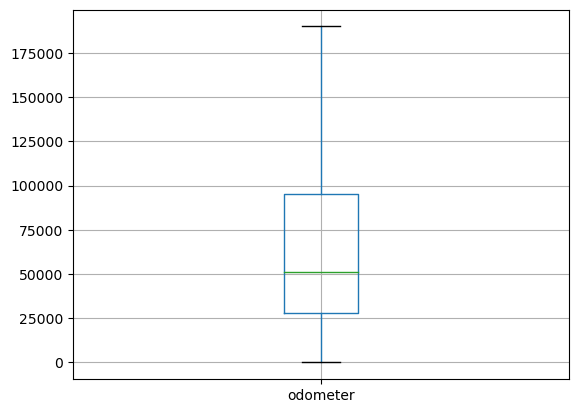

In [16]:
data_train.boxplot("odometer")

In [17]:
full_data = pd.concat([data_train, data_test])

In [18]:
cats = getfullitemsforOHE(full_data, CATIGORIES_COLUMNS)

In [19]:
ohe=OneHotEncoder(categories=cats, sparse=False, handle_unknown="ignore", drop='first')

X_train = ohe.fit_transform(data_train[CATIGORIES_COLUMNS])
ohe_train = pd.DataFrame(X_train,columns=ohe.get_feature_names_out(CATIGORIES_COLUMNS))

X_test = ohe.fit_transform(data_test[CATIGORIES_COLUMNS])
ohe_test = pd.DataFrame(X_test,columns=ohe.get_feature_names_out(CATIGORIES_COLUMNS))

c:\Users\Rog\Desktop\Programing\Python\envs\Kaggle\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Users\Rog\Desktop\Programing\Python\envs\Kaggle\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [20]:
data_train = data_train.drop(CATIGORIES_COLUMNS, axis=1)
data_train = data_train.join(ohe_train)

data_test = data_test.drop(CATIGORIES_COLUMNS, axis=1)
data_test = data_test.join(ohe_test)

In [21]:
features = data_train.drop(["sellingprice"], axis=1)
target = data_train["sellingprice"]

In [22]:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.15, random_state=RANDOM_STATE, shuffle=True)

In [23]:
cat = CatBoostRegressor(n_estimators=500, depth=16, random_state=RANDOM_STATE, silent=True, task_type="GPU", devices="0:1")

In [25]:
cat.fit(features_train, target_train, eval_set=(features_test, target_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [26]:
results = pd.DataFrame(pd.read_csv("./used-cars-price-prediction-19ds/test.csv")["vin"]).join(pd.DataFrame(cat.predict(data_test)))

In [27]:
results.columns = ["vin", "sellingprice"]

In [28]:
normal_result = pd.read_csv("results.csv")["sellingprice"]

In [29]:
normal_result.describe()

count    110058.000000
mean      13641.439196
std        9453.718142
min       -2929.138474
25%        6982.244486
50%       12226.033372
75%       18314.765488
max      156345.873779
Name: sellingprice, dtype: float64

In [30]:
res = cat.predict(features_test)

In [31]:
print(mean_absolute_percentage_error(results["sellingprice"], normal_result))

0.20500574807081942


In [32]:
print(mean_absolute_error(target_test, res))

1528.861327111807


In [33]:
results.to_csv("result.csv", index=False)